In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 44.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6

Note that authentication is required to access data through the package, please follow the instructions [here](https://malariagen.github.io/vector-data/vobs/vobs-data-access.html).

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [ ]:
#import os
#os.environ["MGEN_SHOW_PROGRESS"] = "0"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : Iowa, United States (Google Cloud us-central1)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
ttra_haps = ag3.haplotypes(region="2L:17066531 - 17082025",
                           sample_sets="3.0")

In [ ]:
tpp_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(ttra_haps["variant_position"].values))
pos.shape

(5649,)

## Extract the haplotype itself

In [8]:
gt = ttra_haps["call_genotype"].values

In [ ]:
gt.shape

(653, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [9]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [10]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(5649, 5568)

In [ ]:
haps

<HaplotypeArray shape=(5649, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
pos

0,1,2,3,4,...,5644,5645,5646,5647,5648
np.int32(17066533),np.int32(17066543),np.int32(17066557),np.int32(17066559),np.int32(17066560),...,np.int32(17082017),np.int32(17082018),np.int32(17082019),np.int32(17082023),np.int32(17082024)


## Define the Transcript and the Cohort to work with

In [11]:
transcript = "AGAP005563-RB"

In [12]:
cohorts = "admin1_year"

## Call the SNPs in that transcript

In [13]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/149 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/54 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/46485 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
2L     17066531 A          C          NaN                       True   
                           T          NaN                       True   
                           G          NaN                       True   
       17066532 G          A          NaN                       True   
                           C          NaN                       True   
...                                                              ...   
       17082024 A          T          NaN                       True   
                           G          NaN                       True   
       17082025 G          A          NaN                       True   
                           C          NaN                       True   
                           T          NaN                       True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
2L     17066531 A          C          NaN                  True       True   
                           T          NaN                  True       True   
                           G          NaN                  True       True   
       17066532 G          A          NaN                  True       True   
                           C          NaN                  True       True   
...                                                         ...        ...   
       17082024 A          T          NaN                  True       True   
                           G          NaN                  True       True   
       17082025 G          A          NaN                  True       True   
                           C          NaN                  True       True   
                           T          NaN                  True       True   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
2L     17066531 A          C          NaN                         0.0   
                           T          NaN                         0.0   
                           G          NaN                         0.0   
       17066532 G          A          NaN                         0.0   
                           C          NaN                         0.0   
...                                                               ...   
       17082024 A          T          NaN                         0.0   
                           G          NaN                         0.0   
       17082025 G          A          NaN                         0.0   
                           C          NaN                         0.0   
                           T          NaN                         0.0   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
2L     17066531 A          C          NaN                        0.0   
                           T          NaN                        0.0   
                           G          NaN                        0.0   
       17066532 G          A          NaN                        0.0   
                           C          NaN                        0.0   
...                                                              ...   
       17082024 A          T          NaN                        0.0   
                           G          NaN                        0.0   
       17082025 G          A          NaN                        0.0   
                           C          NaN                        0.0   
                           T          NaN                        0.0   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
2L     17066531 A          C          NaN                        0

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [14]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
2L     17067237 G          T          G9V                       True   
       17067269 C          A          P20T                      True   
       17071051 A          C          Y46S                     False   
       17071063 G          A          R50H                      True   
       17071164 C          A          P84T                      True   
       17071165 C          A          P84Q                     False   
       17071168 G          A          R85H                      True   
       17071170 A          G          T86A                     False   
       17071171 C          T          T86I                      True   
       17071174 T          A          L87H                      True   
       17071177 A          C          Q88P                      True   
       17071181 T          G          H89Q                      True   
       17071193 G          C          Q93H                      True   
       17071249 T          G          V112G                     True   
       17071268 G          C          K118N                    False   
       17071398 T          A          S162T                     True   
       17071529 A          C          K183T                     True   
       17071549 G          T          V190L                     True   
       17071558 G          T          A193S                     True   
       17071568 T          G          L196R                    False   
       17071591 T          G          S204A                     True   
       17071628 T          A          F216Y                    False   
       17071745 T          G          I255S                     True   
       17071979 A          T          T308S                     True   
       17072014 C          G          F319L                    False   
       17078024 T          C          F362S                    False   
       17078096 A          G          D386G                     True   
       17079041 T          A          S430T                     True   
       17079244 G          C          G475R                     True   
       17079305 C          T          A495V                     True   
       17079548 T          A          L576Q                     True   
       17079907 G          A          V696I                     True   
       17079919 C          A          L700I                     True   
       17079940 T          C          W707R                    False   
       17079946 A          G          M709V                     True   
       17079994 G          T          V725F                     True   
       17080256 C          A          D782E                     True   
       17080270 T          G          M787R                     True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
2L     17067237 G          T          G9V                  True       True   
       17067269 C          A          P20T                 True       True   
       17071051 A          C          Y46S                 True      False   
       17071063 G          A          R50H                 True       True   
       17071164 C          A          P84T                 True       True   
       17071165 C          A          P84Q                 True      False   
       17071168 G          A          R85H                 True       True   
       17071170 A          G          T86A                False       True   
       17071171 C          T          T86I                 True       True   
       17071174 T          A          L87H                 True       True   
       17071177 A          C          Q88P                 True       True   
       17071181 T          G          H89Q                 True       True   
       17071193 G          C          Q93H                 True       True  

## Extract the indexes

In [15]:
ttrb_index = missense_variants[[]]
ttrb_index


Empty DataFrame
Columns: []
Index: [(2L, 17067237, G, T, G9V), (2L, 17067269, C, A, P20T), (2L, 17071051, A, C, Y46S), (2L, 17071063, G, A, R50H), (2L, 17071164, C, A, P84T), (2L, 17071165, C, A, P84Q), (2L, 17071168, G, A, R85H), (2L, 17071170, A, G, T86A), (2L, 17071171, C, T, T86I), (2L, 17071174, T, A, L87H), (2L, 17071177, A, C, Q88P), (2L, 17071181, T, G, H89Q), (2L, 17071193, G, C, Q93H), (2L, 17071249, T, G, V112G), (2L, 17071268, G, C, K118N), (2L, 17071398, T, A, S162T), (2L, 17071529, A, C, K183T), (2L, 17071549, G, T, V190L), (2L, 17071558, G, T, A193S), (2L, 17071568, T, G, L196R), (2L, 17071591, T, G, S204A), (2L, 17071628, T, A, F216Y), (2L, 17071745, T, G, I255S), (2L, 17071979, A, T, T308S), (2L, 17072014, C, G, F319L), (2L, 17078024, T, C, F362S), (2L, 17078096, A, G, D386G), (2L, 17079041, T, A, S430T), (2L, 17079244, G, C, G475R), (2L, 17079305, C, T, A495V), (2L, 17079548, T, A, L576Q), (2L, 17079907, G, A, V696I), (2L, 17079919, C, A, L700I), (2L, 17079940, T, C, W707R), (2L, 17079946, A, G, M709V), (2L, 17079994, G, T, V725F), (2L, 17080256, C, A, D782E), (2L, 17080270, T, G, M787R)]

## Conver the object to a dataframe

In [16]:
ttrb_df = pd.DataFrame(list(ttrb_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
ttrb_df

,contig,position,ref_allele,alt_allele,aa_change
0,2L,17067237,G,T,G9V
1,2L,17067269,C,A,P20T
2,2L,17071051,A,C,Y46S
3,2L,17071063,G,A,R50H
4,2L,17071164,C,A,P84T
5,2L,17071165,C,A,P84Q
6,2L,17071168,G,A,R85H
7,2L,17071170,A,G,T86A
8,2L,17071171,C,T,T86I
9,2L,17071174,T,A,L87H


## Sort the positions of the selected variants

In [17]:
pos_selected = allel.SortedIndex(sorted(ttrb_df['position']))

In [ ]:
pos_selected

0,1,2,3,4,5,6
np.int64(17071164),np.int64(17071171),np.int64(17071174),np.int64(17071177),np.int64(17071181),np.int64(17071398),np.int64(17071979)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [18]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, ..., False, False, False])

## Use said file to select the haplotypes corresponding to the selected positions

In [19]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(23, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [20]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [21]:
values_to_remove = get_missing_values(pos_selected, pos)

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [22]:
ttrb_df2 = ttrb_df[~ttrb_df["position"].isin(values_to_remove)]
ttrb_df2.shape

(23, 5)

## this creates a dataframe to show which mutations were not present and were subsequently removed

In [23]:
ttrb_mut = ttrb_df[ttrb_df["position"].isin(values_to_remove)]
ttrb_mut.shape

(15, 5)

In [24]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5557,11
1,5565,3
2,5567,1
3,5558,10
4,5520,48
5,5566,2
6,5557,11
7,5567,1
8,5567,1
9,5550,18


## Define the function to compute the Lenwontin D'

In [25]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [26]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [27]:
ttrb_df2["label"] = (
    ttrb_df2["position"].astype(str)
    + ": "
    + ttrb_df2["ref_allele"].astype(str)
    + ">"
    + ttrb_df2["alt_allele"].astype(str)
    + " "
    + ttrb_df2["aa_change"]
)
ttrb_df2

/tmp/ipython-input-1887985615.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
0,2L,17067237,G,T,G9V,17067237: G>T G9V
1,2L,17067269,C,A,P20T,17067269: C>A P20T
6,2L,17071168,G,A,R85H,17071168: G>A R85H
9,2L,17071174,T,A,L87H,17071174: T>A L87H
11,2L,17071181,T,G,H89Q,17071181: T>G H89Q
13,2L,17071249,T,G,V112G,17071249: T>G V112G
15,2L,17071398,T,A,S162T,17071398: T>A S162T
16,2L,17071529,A,C,K183T,17071529: A>C K183T
17,2L,17071549,G,T,V190L,17071549: G>T V190L
18,2L,17071558,G,T,A193S,17071558: G>T A193S


## create an array of your labels to be used

In [28]:
labels = ttrb_df2["label"].to_numpy()

In [29]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [30]:
ld_df.to_excel("ttrbld_matrix.xlsx")

## Plotting the heatmap

##define a function that plots your heatmap with gridspace

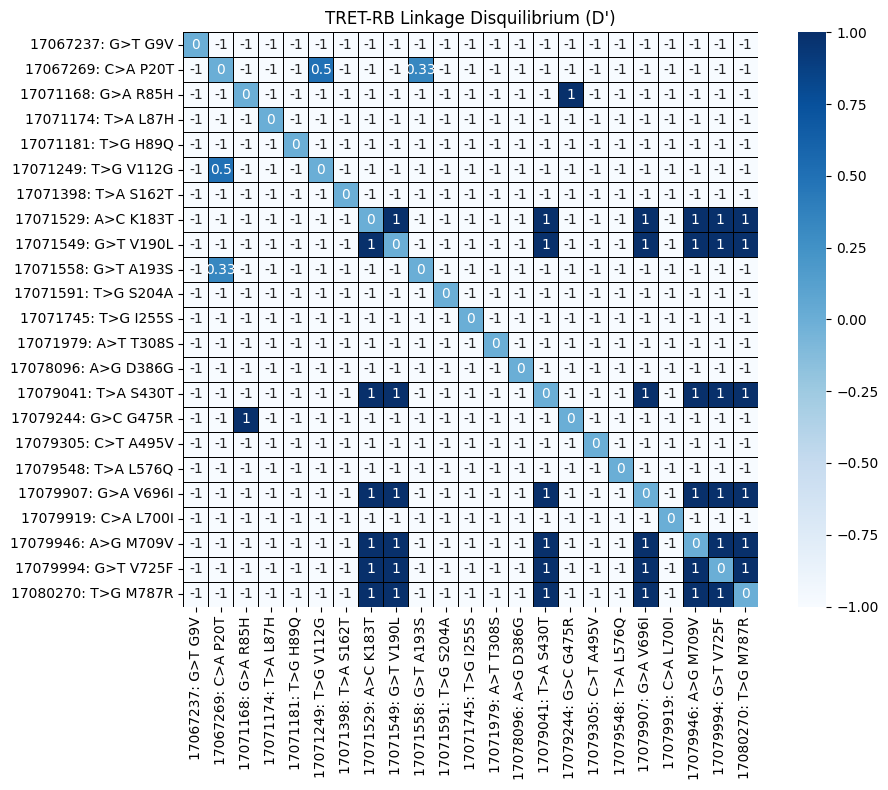

In [31]:
def plot_ld_with_gridspec(ld_df, title="TRET-RB Linkage Disquilibrium (D')"):
    n = ld_df.shape[0]

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])


    sns.heatmap(
        ld_df,
        cmap="Blues",
        annot=True,
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.5,
        linecolor="black",
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


plot_ld_with_gridspec(ld_df)
